# Pareto Front Visualization — Proposed vs Baselines

Objective space: $F_0 = -\text{Accuracy}$ (minimise), $F_1 = \text{Latency (ms)}$ (minimise).  
Step-plots trace the staircase Pareto frontier; scatter shows all evaluated architectures.

**Reference**: All JSON archives in `results/`.

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto
)

RESULTS_DIR = PROJECT_ROOT / "results"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [14]:
def load_archives(glob_pattern: str) -> list[list[dict]]:
    """Load all JSON archives matching glob_pattern relative to RESULTS_DIR."""
    archives = []
    for p in sorted(RESULTS_DIR.glob(glob_pattern)):
        payload = json.loads(p.read_text())
        archives.append(payload["archive"])
    return archives

proposed_archives  = load_archives("proposed/proposed_res_*.json")
nsga2_archives     = load_archives("baselines/nsga2_seed*.json")
random_archives    = load_archives("baselines/random_search_seed*.json")

print(f"Proposed runs : {len(proposed_archives)}")
print(f"NSGA-II runs  : {len(nsga2_archives)}")
print(f"Random Search : {len(random_archives)}")

Proposed runs : 30
NSGA-II runs  : 30
Random Search : 30


In [15]:
def aggregate_front(archives: list[list[dict]]) -> np.ndarray:
    """Union all runs → extract aggregate non-dominated front in (accuracy, latency) space."""
    if not archives:
        return np.empty((0, 2))
    all_pts = np.vstack([archive_to_points(a) for a in archives])  # (-acc, lat)
    front = get_pareto_front(all_pts)
    # Convert back to display space: (accuracy, latency)
    return np.column_stack([-front[:, 0], front[:, 1]])

front_proposed = aggregate_front(proposed_archives)
front_nsga2    = aggregate_front(nsga2_archives)
front_random   = aggregate_front(random_archives)

print(f"Non-dominated sizes — Proposed: {len(front_proposed)}, "
      f"NSGA-II: {len(front_nsga2)}, Random: {len(front_random)}")

Non-dominated sizes — Proposed: 3752, NSGA-II: 463, Random: 109


In [16]:
# ── Compute HV and IGD (proxy P* = union of all algorithms) ──────────────
all_archives = proposed_archives + nsga2_archives + random_archives
p_star = proxy_pareto(all_archives)  # (K, 2) in minimisation space

# Normalise for cross-algorithm HV comparison
all_pts_min = p_star.min(axis=0)
all_pts_max = p_star.max(axis=0)
range_ = np.where(all_pts_max - all_pts_min > 0, all_pts_max - all_pts_min, 1.0)

def normalise(pts: np.ndarray) -> np.ndarray:
    return (pts - all_pts_min) / range_

REF = np.array([1.1, 1.1])

def hv_igd(archives, label):
    if not archives:
        print(f"{label}: no data")
        return
    pts = np.vstack([archive_to_points(a) for a in archives])
    front = get_pareto_front(pts)
    hv  = calc_hv(normalise(front), ref_point=REF)
    igd = calc_igd(normalise(front), normalise(p_star))
    print(f"{label:20s}  HV={hv:.6f}   IGD={igd:.6f}")

hv_igd(proposed_archives, "Proposed (MOEA/D+PSO)")
hv_igd(nsga2_archives,    "NSGA-II")
hv_igd(random_archives,   "Random Search")

Proposed (MOEA/D+PSO)  HV=1.050248   IGD=0.000000
NSGA-II               HV=1.050248   IGD=0.000000
Random Search         HV=1.049743   IGD=0.000305


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/pareto_front.pdf


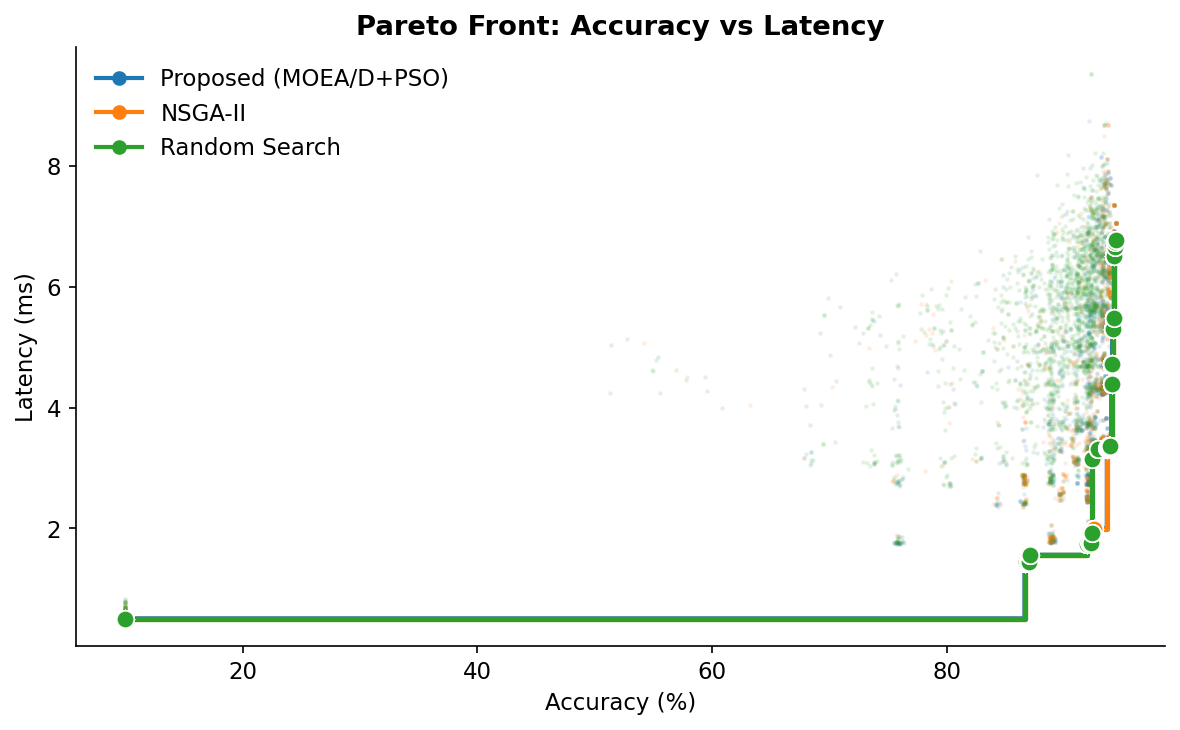

In [17]:
# ── Scatter + Pareto step-plot ────────────────────────────────────────────
CONFIGS = [
    (proposed_archives, front_proposed, "#1f77b4", "Proposed (MOEA/D+PSO)"),
    (nsga2_archives,    front_nsga2,    "#ff7f0e", "NSGA-II"),
    (random_archives,   front_random,   "#2ca02c", "Random Search"),
]

fig, ax = plt.subplots(figsize=(8, 5))

legend_handles = []
for archives, front, color, label in CONFIGS:
    if not archives:
        continue

    # Sample up to 2000 points for the scatter to keep the visual clean.
    all_pts = np.vstack([archive_to_points(a) for a in archives])
    if len(all_pts) > 2000:
        rng = np.random.default_rng(42)
        sample_idx = rng.choice(len(all_pts), size=2000, replace=False)
        all_pts = all_pts[sample_idx]

    ax.scatter(-all_pts[:, 0], all_pts[:, 1],
               color=color, alpha=0.08, s=8, marker='.', zorder=1)

    # Non-dominated step-plot for the aggregate Pareto frontier.
    if len(front) > 0:
        srt = front[np.argsort(front[:, 0])]         # sort by accuracy ascending
        ax.plot(srt[:, 0], srt[:, 1],
                drawstyle='steps-post', color=color, linewidth=2.5, zorder=4)
        ax.scatter(srt[:, 0], srt[:, 1],
                   color=color, edgecolors='white', s=70, linewidths=0.8, zorder=5)
        legend_handles.append(
            mlines.Line2D([], [], color=color, linewidth=2,
                          marker="o", markersize=6, label=label)
        )

ax.set_xlabel("Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Pareto Front: Accuracy vs Latency", fontweight="bold")
ax.legend(handles=legend_handles, frameon=False)
fig.tight_layout()

out = PROJECT_ROOT / "results" / "pareto_front.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Saved EAF Plot → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/eaf_pareto_front.pdf


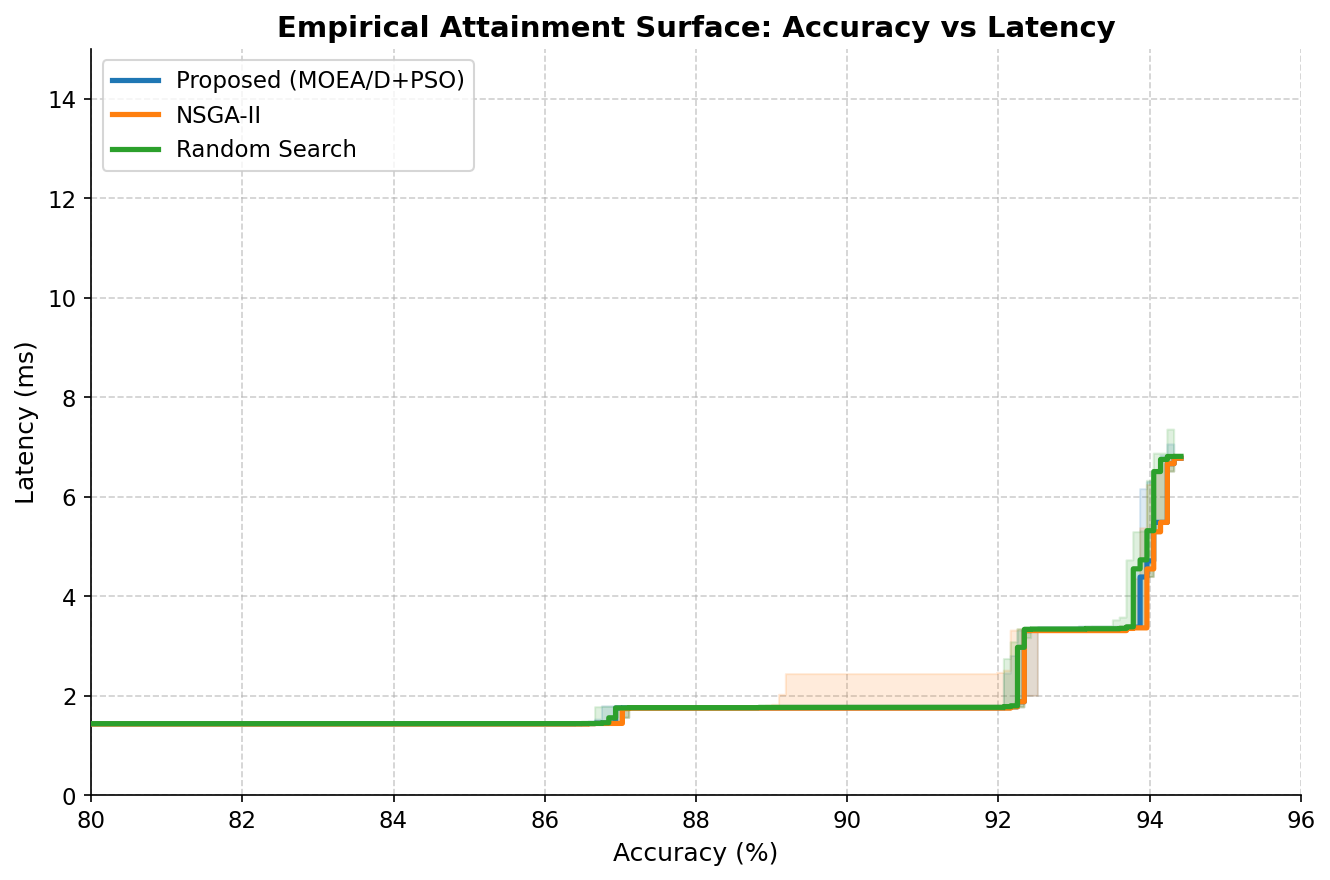

In [18]:
# ── Advanced Visualization: Empirical Attainment Surfaces (EAF) ──────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

# Assume PROJECT_ROOT is defined, e.g., PROJECT_ROOT = Path(".")

# Helper function to extract a single non-dominated front from a set of points
def get_individual_front(pts):
    # pts shape: (N, 2) where col 0 is -Accuracy (minimization) and col 1 is Latency
    # Convert to maximization for Accuracy to make sorting easier
    acc = -pts[:, 0]
    lat = pts[:, 1]
    
    # Sort by accuracy descending
    sort_idx = np.argsort(-acc)
    acc, lat = acc[sort_idx], lat[sort_idx]
    
    front_acc, front_lat = [], []
    min_l = np.inf
    for a, l in zip(acc, lat):
        if l < min_l:
            min_l = l
            front_acc.append(a)
            front_lat.append(l)
            
    # Return sorted by accuracy ascending for plotting
    front = np.column_stack((front_acc, front_lat))
    return front[np.argsort(front[:, 0])]

# Helper function to evaluate attained latency over a continuous accuracy grid
def get_attained_latency(front, x_grid):
    y_attained = np.full(len(x_grid), np.nan)
    for i, x in enumerate(x_grid):
        # Find all points on the front that achieve AT LEAST this accuracy
        valid = front[front[:, 0] >= x]
        if len(valid) > 0:
            # The latency we must accept is the minimum latency among these valid points
            y_attained[i] = np.min(valid[:, 1])
    return y_attained

# Create a shared X-axis grid (Accuracy from 0% to 100%) to evaluate all seeds
x_grid = np.linspace(10, 100, 1000)

CONFIGS = [
    (proposed_archives, "#1f77b4", "Proposed (MOEA/D+PSO)"),
    (nsga2_archives,    "#ff7f0e", "NSGA-II"),
    (random_archives,   "#2ca02c", "Random Search"),
]

fig, ax = plt.subplots(figsize=(9, 6))
legend_handles = []

for archives, color, label in CONFIGS:
    if not archives:
        continue
        
    all_seed_latencies = []
    
    # Process each seed independently
    for a in archives:
        # Convert archive to points (Assuming output is [-Acc, Lat])
        pts = archive_to_points(a) 
        if len(pts) == 0: continue
            
        # Get Pareto front for this specific seed
        front = get_individual_front(pts)
        
        # Calculate the latency this seed attained across the accuracy grid
        y_attained = get_attained_latency(front, x_grid)
        all_seed_latencies.append(y_attained)
        
    all_seed_latencies = np.array(all_seed_latencies)
    
    # If we have valid runs, calculate EAF statistics (ignore NaNs where accuracy wasn't reached)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        best_case = np.nanmin(all_seed_latencies, axis=0)
        worst_case = np.nanmax(all_seed_latencies, axis=0)
        median_case = np.nanmedian(all_seed_latencies, axis=0)
    
    # Plot the Shaded Confidence Interval (Worst to Best case)
    ax.fill_between(x_grid, best_case, worst_case, color=color, alpha=0.15, step='post', zorder=2)
    
    # Plot the Median line
    ax.plot(x_grid, median_case, drawstyle='steps-post', color=color, linewidth=2.5, zorder=4)
    
    # Add to legend
    legend_handles.append(
        mlines.Line2D([], [], color=color, linewidth=2.5, label=label)
    )

ax.set_xlabel("Accuracy (%)", fontsize=12)
ax.set_ylabel("Latency (ms)", fontsize=12)
ax.set_title("Empirical Attainment Surface: Accuracy vs Latency", fontweight="bold", fontsize=14)

# Adjust axes to zoom in on the interesting part of the Pareto front
ax.set_xlim(80, 96)  # Adjust these bounds based on your actual data
ax.set_ylim(0, 15)

ax.legend(handles=legend_handles, frameon=True, fontsize=11, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()

# Save the figure
out = PROJECT_ROOT / "results" / "eaf_pareto_front.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight")
print(f"Saved EAF Plot → {out}")
plt.show()